# Quantize And Test Model

This notebook first quantizes the trained Keras model into an INT8 TensorFlow Lite model using cached training data for representative calibration. It exports the generated `model.tflite`, `model.c`, and `model.h` files into `gen/`, then evaluates the quantized TFLite model on the cached test set below.

In [ ]:
from pathlib import Path

import os

import keras
import numpy as np
import tensorflow as tf

from preprocess import NUM_CLASSES, LABELS
from utils.export_tflite import write_model_c_file, write_model_h_file

# Minimize TensorFlow logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")

SCRIPT_DIR = Path.cwd()
GEN_DIR = SCRIPT_DIR / "quantized_model"
SAVED_MODEL_DIR = SCRIPT_DIR / "saved_model"
MODEL_PATH = SAVED_MODEL_DIR / "mobilenetv2_3class_classifier.keras"
X_TRAIN_PATH = SAVED_MODEL_DIR / "x_train.npy"
MODEL_TFLITE_PATH = GEN_DIR / "model.tflite"
MODEL_C_PATH = GEN_DIR / "model.c"
MODEL_H_PATH = GEN_DIR / "model.h"
REPRESENTATIVE_DATASET_SAMPLES = 512


def representative_indices(num_samples: int, max_samples: int = REPRESENTATIVE_DATASET_SAMPLES) -> np.ndarray:
    """Pick a deterministic, evenly spread calibration subset."""
    if num_samples <= 0:
        raise ValueError("Representative dataset requires at least one sample.")
    if num_samples <= max_samples:
        return np.arange(num_samples, dtype=np.int32)
    return np.linspace(0, num_samples - 1, num=max_samples, dtype=np.int32)


def export_model_to_tflite(model: keras.Model, x_train: np.ndarray) -> bytes:
    """Convert a Keras model to full INT8 TFLite."""
    print("Converting to TensorFlow Lite model with INT8 quantization...")
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    def representative_dataset():
        # Use a deterministic, evenly spread subset for stable calibration.
        indices = representative_indices(len(x_train))
        for i in indices:
            yield [x_train[i:i + 1].astype(np.float32)]

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    return converter.convert()


def resolve_model_img_size(model: keras.Model) -> int:
    """Read the square input size directly from the loaded Keras model."""
    input_shape = model.input_shape
    if isinstance(input_shape, list):
        input_shape = input_shape[0]

    if len(input_shape) != 4:
        raise ValueError(f"Expected 4D model input shape, got {input_shape}")

    height = input_shape[1]
    width = input_shape[2]
    channels = input_shape[3]

    if height is None or width is None or channels is None:
        raise ValueError(f"Model input shape must be fully defined, got {input_shape}")
    if channels != 3:
        raise ValueError(f"Expected 3 input channels, got {channels}")
    if height != width:
        raise ValueError(f"Expected square model input, got {height}x{width}")

    return int(height)


def export_artifacts(tflite_model: bytes, img_size: int):
    """Write TFLite and C export artifacts."""
    GEN_DIR.mkdir(exist_ok=True)

    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_scale, input_zero_point = input_details[0]["quantization"]
    output_scale, output_zero_point = output_details[0]["quantization"]

    print(f"Input scale:       {input_scale}")
    print(f"Input zero point:  {input_zero_point}")
    print(f"Output scale:      {output_scale}")
    print(f"Output zero point: {output_zero_point}")
    print(f"Model size:        {len(tflite_model) / 1024:.1f} KB")

    defines = {
        "IMG_SIZE": img_size,
        "NUM_CLASSES": NUM_CLASSES,
        "INPUT_SCALE": f"{input_scale}f",
        "INPUT_ZERO_POINT": input_zero_point,
        "OUTPUT_SCALE": f"{output_scale}f",
        "OUTPUT_ZERO_POINT": output_zero_point,
    }
    declarations = [
        f'// Labels: {", ".join(f"{name}={idx}" for name, idx in sorted(LABELS.items(), key=lambda x: x[1]))}',
    ]

    write_model_h_file(MODEL_H_PATH, defines, declarations)
    write_model_c_file(MODEL_C_PATH, tflite_model)

    with open(MODEL_TFLITE_PATH, "wb") as f:
        f.write(tflite_model)

    print(f"Saved: {MODEL_TFLITE_PATH}")
    print(f"Saved: {MODEL_C_PATH}")
    print(f"Saved: {MODEL_H_PATH}")

model_path = MODEL_PATH.resolve()
x_train_path = X_TRAIN_PATH.resolve()

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found: {model_path}")
if not os.path.exists(x_train_path):
    raise FileNotFoundError(
        f"Calibration data not found: {x_train_path}. Run preprocess.py first or pass --x-train."
    )

print(f"Loading Keras model: {model_path}")
model = keras.models.load_model(model_path)
img_size = resolve_model_img_size(model)

print(f"Loading calibration data: {x_train_path}")
x_train = np.load(x_train_path)
if x_train.ndim != 4:
    raise ValueError(f"Expected x_train to be 4D, got shape {x_train.shape}")
if x_train.shape[1] != img_size or x_train.shape[2] != img_size or x_train.shape[3] != 3:
    raise ValueError(
        f"Calibration data shape {x_train.shape} does not match model input "
        f"(None, {img_size}, {img_size}, 3)"
    )

tflite_model = export_model_to_tflite(model, x_train)
export_artifacts(tflite_model, img_size)


# Test Quantized TFLite Model

This notebook evaluates `gen/model.tflite` on the cached test set. If the cached test arrays are missing, it regenerates them with `preprocess.py`. If the cached spatial size differs from the exported model input size, it resizes the test images before quantized inference.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from preprocess import DATA_DIR, LABELS, NUM_CLASSES, preprocess_all

In [ ]:
SCRIPT_DIR = Path.cwd()
GEN_DIR = SCRIPT_DIR / "gen"
MODEL_PATH = GEN_DIR / "model.tflite"
X_TEST_PATH = GEN_DIR / "x_test.npy"
Y_TEST_PATH = GEN_DIR / "y_test.npy"

print("Model:", MODEL_PATH)
print("x_test:", X_TEST_PATH)
print("y_test:", Y_TEST_PATH)

Model: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\gen\model.tflite
x_test: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\gen\x_test.npy
y_test: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\gen\y_test.npy


In [ ]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing quantized model: {MODEL_PATH}")

if not X_TEST_PATH.exists() or not Y_TEST_PATH.exists():
    print("Cached test arrays missing. Running preprocessing to regenerate them...")
    preprocess_all(str(DATA_DIR), str(GEN_DIR))

if not X_TEST_PATH.exists():
    raise FileNotFoundError(f"Missing test features after preprocessing: {X_TEST_PATH}")
if not Y_TEST_PATH.exists():
    raise FileNotFoundError(f"Missing test labels after preprocessing: {Y_TEST_PATH}")

x_test = np.load(X_TEST_PATH)
y_test = np.load(Y_TEST_PATH)

print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_test shape: (540, 96, 96, 3)
y_test shape: (540,)


In [ ]:
if x_test.ndim != 4:
    raise ValueError(f"Expected x_test to be 4D, got shape {x_test.shape}")
if y_test.ndim != 1:
    raise ValueError(f"Expected y_test to be 1D, got shape {y_test.shape}")
if len(x_test) != len(y_test):
    raise ValueError(f"Mismatched test set sizes: {len(x_test)} vs {len(y_test)}")

In [ ]:
interpreter = tf.lite.Interpreter(model_path=str(MODEL_PATH))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("Input details:", input_details)
print("Output details:", output_details)

Input details: {'name': 'serving_default_input_4:0', 'index': 0, 'shape': array([  1, 160, 160,   3]), 'shape_signature': array([ -1, 160, 160,   3]), 'dtype': <class 'numpy.int8'>, 'quantization': (0.007843137718737125, -1), 'quantization_parameters': {'scales': array([0.00784314], dtype=float32), 'zero_points': array([-1]), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
Output details: {'name': 'StatefulPartitionedCall:0', 'index': 180, 'shape': array([1, 3]), 'shape_signature': array([-1,  3]), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128]), 'quantized_dimension': 0}, 'sparsity_parameters': {}}


In [ ]:
input_shape = tuple(input_details["shape"])
if input_shape[0] != 1 or input_shape[3] != 3:
    raise ValueError(f"Unexpected model input shape: {input_shape}")

expected_spatial_shape = tuple(input_shape[1:])
if x_test.shape[1:] != expected_spatial_shape:
    print(
        "Resizing cached test data from "
        f"{x_test.shape[1:]} to {expected_spatial_shape} to match the exported model."
    )
    x_test = tf.image.resize(x_test, input_shape[1:3], method="bilinear").numpy().astype(np.float32)

if input_details["dtype"] != np.int8:
    raise ValueError(f"Expected int8 input tensor, got {input_details['dtype']}")

Resizing cached test data from (96, 96, 3) to (160, 160, 3) to match the exported model.


In [ ]:
input_scale, input_zero_point = input_details["quantization"]
output_scale, output_zero_point = output_details["quantization"]

x_test_quantized = x_test / input_scale + input_zero_point
x_test_quantized = np.clip(x_test_quantized, -128, 127).astype(np.int8)

raw_predictions = np.empty((len(x_test), NUM_CLASSES), dtype=np.int8)
for i in range(len(x_test)):
    interpreter.set_tensor(input_details["index"], x_test_quantized[i:i + 1])
    interpreter.invoke()
    raw_predictions[i] = interpreter.get_tensor(output_details["index"])[0]

predictions = (raw_predictions.astype(np.float32) - output_zero_point) * output_scale
y_pred = np.argmax(predictions, axis=1)

In [ ]:
accuracy = np.mean(y_pred == y_test)
class_names = [name for name, _ in sorted(LABELS.items(), key=lambda item: item[1])]
cm = confusion_matrix(y_test, y_pred)

print(f"Model: {MODEL_PATH}")
print(f"Test samples: {len(x_test)}")
print(f"Quantized accuracy: {accuracy:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))
print("Confusion matrix:")
print(cm)

Model: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\gen\model.tflite
Test samples: 540
Quantized accuracy: 0.8407

Classification report:
              precision    recall  f1-score   support

       Amine     0.9122    0.7500    0.8232       180
       Rifki     0.8186    0.9278    0.8698       180
       Jakub     0.8085    0.8444    0.8261       180

    accuracy                         0.8407       540
   macro avg     0.8464    0.8407    0.8397       540
weighted avg     0.8464    0.8407    0.8397       540

Confusion matrix:
[[135  18  27]
 [  4 167   9]
 [  9  19 152]]


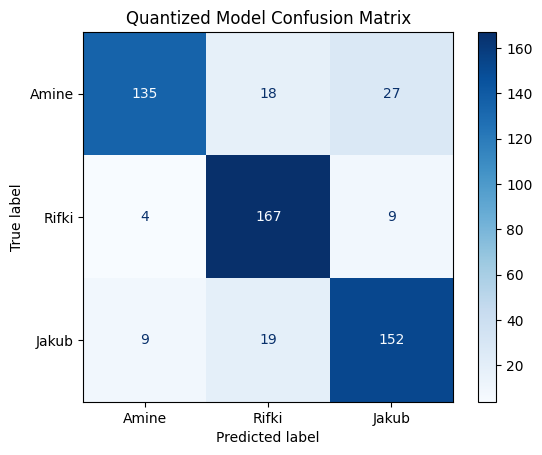

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Quantized Model Confusion Matrix")
plt.show()